# Nova Pay Fraud Detection - Step 5 & 6
## Model Development, Tuning, Validation & Explainability

**Workflow position:** This notebook follows directly from `data_cleaning.ipynb` (Steps 1-2) and `EDA.ipynb` (Steps 3-4). It consumes the engineered, standardized, one-hot encoded dataset saved by EDA at `../data/nova_pay_engineered_scaled.csv`.

---

### Step 5 — Model Development (developed, tuned & compared)
- Progress from **Logistic Regression** and **Random Forest** baselines to advanced **XGBoost** and **LightGBM** models
- Tune hyperparameters
- Compare performance using **confusion matrix, recall, precision, F1-score, and ROC-AUC**

### Step 6 — Validation & Explainability (validated & interpreted)
- Conduct rigorous **holdout evaluation**
- Generate **SHAP** values for transaction-level reasoning and to build trust in model decisions

---

**Modelling note on class imbalance:** Fraud is a rare event (~minority class). Throughout this notebook we optimize and report metrics that are robust to imbalance — **recall, precision, F1, ROC-AUC, and PR-AUC** — rather than raw accuracy, and we use class weighting / `scale_pos_weight` instead of resampling so that probability calibration and SHAP attributions remain faithful to the real population.

---
## 📚 HOW THE CLEANING & EDA DECISIONS SHAPE THIS NOTEBOOK

This notebook does not stand alone — every modelling result here is a **direct consequence of choices made upstream** in `data_cleaning.ipynb` and `EDA.ipynb`. Before building models, it is worth understanding *which* upstream decision affects *what* here, because in machine learning the data preparation usually matters more than the model choice. We will revisit each of these at the exact cell where its impact appears.

| Upstream decision (where) | Downstream impact (here) |
|---|---|
| **Separated identifiers** out of the feature set (EDA 3.10b) | The feature matrix has ~40–80 columns, not ~25,000. Models train in seconds, not hours, and don't overfit to row-specific IDs. *(See Step 2 & 3.)* |
| **Built behaviour features** from IDs — `customer_total_transactions`, `customer_device_count` (cleaning Step 9) | These become some of the model's *most predictive inputs* and show up at the top of the SHAP importance plot. The identity was discarded; the behaviour was kept. *(See Step 6.5.)* |
| **One-hot encoded** low-cardinality categories with `drop_first=True` (EDA 3.10) | Features like `channel`, `kyc_tier`, `currency_pair` arrive as clean 0/1 columns the model can use — with no false ordering and no dummy-variable trap. *(See Step 3.)* |
| **KNN imputation** of missing numeric values (cleaning Step 7) | No missing cells reach the model, so training never errors out, and the imputed values preserve the real distribution rather than flattening it to a median. *(See Step 4 safety net.)* |
| **Outlier capping** to the 99th percentile (cleaning Step 6) | Extreme values don't dominate scaling or distort tree splits, so the model learns typical fraud patterns rather than chasing a handful of giant transactions. |
| **StandardScaler** on numeric features (EDA 3.9) | Logistic Regression (distance/scale-sensitive) trains fairly; the "fill missing with 0" safety net here is valid *only because* 0 = the post-scaling mean. *(See Step 4.)* |
| **Documented class imbalance** ~8–9% fraud (cleaning Step 10) | Drives every modelling choice here: stratified splits, `class_weight`/`scale_pos_weight`, and judging models on PR-AUC/recall instead of accuracy. |

**The throughline:** good cleaning and EDA are not box-ticking. Each decision either *enables* a modelling step or *prevents* a failure mode. As you run this notebook, notice how often a good result traces back to something done before the first model was ever fit.

## STEP 1: INSTALL & IMPORT LIBRARIES

In [25]:
# Install required packages
!pip install pandas numpy scikit-learn matplotlib seaborn scipy xgboost lightgbm shap joblib h5py pyarrow msgpack

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

import xgboost as xgb
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')

# Set visualization defaults 
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

RANDOM_STATE = 42                                               # For reproducibility
np.random.seed(RANDOM_STATE)                                    # Set random seed for numpy

print('✓ All libraries imported successfully')

✓ All libraries imported successfully



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## STEP 2: LOAD ENGINEERED DATASET

### 📚 IMPACT CHECK — column count proves the identifier fix worked

When we load the engineered data, the **first thing to inspect is the column count**. Recall the "why do I have 25,000 columns?" problem: it happened when high-cardinality identifiers were accidentally one-hot encoded. Because EDA Step 3.10b now separates identifiers *before* encoding, this dataset should have only a few dozen columns. The load cell prints `Shape` — treat a sensible column count as confirmation the upstream fix held. If you ever see thousands of columns here, the bug is upstream in EDA, not in the model.

In [26]:
# Load the engineered & scaled dataset produced from EDA
df = pd.read_csv('../data/nova_pay_engineered_scaled.csv')

print('=' * 80)
print('ENGINEERED DATASET LOADED')
print('=' * 80)
print(f'Shape: {df.shape}')
print(f'\nTarget distribution (is_fraud):')
print(df['is_fraud'].value_counts())
print(f'\nFraud rate: {df["is_fraud"].mean():.2%}')
print(f'\nMemory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

# IMPACT READOUT: confirm the identifier-separation fix (expect dozens, not thousands)
print(f'\n📌 Column count: {df.shape[1]}')
if df.shape[1] > 200:
    print('   ⚠️  Unexpectedly high — an identifier may have been one-hot encoded upstream (check EDA 3.10b).')
else:
    print('   ✓ Sensible width — identifier separation upstream worked as intended.')
# Verify behaviour features (derived from identifiers) survived into the model inputs
for f in ['customer_total_transactions', 'customer_device_count']:
    print(f'   {"✓" if f in df.columns else "✗"} behaviour feature present: {f}')

ENGINEERED DATASET LOADED
Shape: (11200, 107)

Target distribution (is_fraud):
is_fraud
0.0    10205
1.0      995
Name: count, dtype: int64

Fraud rate: 8.88%

Memory: 10.43 MB

📌 Column count: 107
   ✓ Sensible width — identifier separation upstream worked as intended.
   ✓ behaviour feature present: customer_total_transactions
   ✓ behaviour feature present: customer_device_count


## STEP 3: PREPARE FEATURES & TARGET

### 3.1 EXPLORE: Identify columns to drop from the model
We drop the target and any identifier columns. We also drop columns that are non-numeric leftovers (the engineered dataset should be fully numeric, but we verify and remove any stragglers such as timestamps so the models receive a clean numeric matrix).

### 📚 IMPACT CHECK — defence in depth: why we re-check for identifiers here

The identifiers were already separated in EDA, so why scan for them *again*? Because robust pipelines **never assume** an upstream step ran. This cell is a safety net: if this notebook is ever run against a dataset where an ID slipped through (a stray `customer_id`, a leftover `timestamp` or `corridor`), the checks below catch it before it can leak into the model or re-trigger the column explosion.

This illustrates a key lesson connecting the notebooks: **each stage validates the assumptions it inherits from the previous stage.** Cleaning trusts the raw data minimally; EDA trusts cleaning's output but still checks; modelling trusts EDA's output but still checks. That layering is what makes a pipeline trustworthy rather than fragile.

In [27]:
print('\n🔍 FEATURE / TARGET PREPARATION EXPLORATION\n')

# Columns that must never be used as predictors
id_target_cols = ['is_fraud', 'customer_id', 'transaction_id']                              # lists the target and identifier columns and puts them in an object 'id_target_cols'
present_id_cols = [c for c in id_target_cols if c in df.columns]                            # Check to verify there is no identifier remaining in the dataset that we missed (e.g. 'id' or 'uid' or 'user_id' etc.) and list which of the known ID/target columns are actually in the dataset
print(f'Identifier/target columns present: {present_id_cols}')                              # report in the format of "Identifier/target columns present: columns found in 'present_id_cols'"

# Detect any non-numeric columns that slipped through (e.g. timestamp, corridor)
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()                        # list all non-numeric columns in the dataset and put them in an object 'non_numeric'
non_numeric = [c for c in non_numeric if c not in id_target_cols]                           # check to verify identifier/target columns are not in the non-numeric list (if they are present, we will drop them later)
print(f'Non-numeric columns to drop (if any): {non_numeric}')

# Any datetime-like string columns
leftover_drop = [c for c in df.columns if c in ['timestamp', 'expected_country', 'corridor', 'currency_pair']] # further check for non-numeric columns that are known to be non-predictive and should be dropped if present (e.g. timestamp, expected_country, corridor, currency_pair)
print(f'Known non-feature columns to drop (if present): {leftover_drop}')


🔍 FEATURE / TARGET PREPARATION EXPLORATION

Identifier/target columns present: ['is_fraud', 'customer_id', 'transaction_id']
Non-numeric columns to drop (if any): ['timestamp', 'device_id', 'new_device', 'ip_address', 'location_mismatch', 'is_weekend', 'is_weekday', 'is_business_hours', 'is_night', 'expected_country', 'corridor']
Known non-feature columns to drop (if present): ['timestamp', 'expected_country', 'corridor']


### 3.2 FIX: Build feature matrix X and target y

In [28]:
drop_cols = set(['is_fraud', 'customer_id', 'transaction_id'])                                          # start with the known ID/target columns to drop
drop_cols |= set(df.select_dtypes(exclude=[np.number]).columns.tolist())

feature_cols = [c for c in df.columns if c not in drop_cols]                                            # final list of feature columns after dropping identifiers, target, and non-numeric columns

X = df[feature_cols].copy()                                                                             # feature matrix with only the predictor columns
y = df['is_fraud'].astype(int).copy()                                                                   # target vector (ensure it's integer type for classification)

# Safety: ensure no missing values reach the models
if X.isnull().sum().sum() > 0:
    print(f'⚠ Found {int(X.isnull().sum().sum())} missing cells — filling with 0 (post-scaling mean).')
    X = X.fillna(0)                                                     # fill any missing values with 0, which is the mean after scaling (since we scaled the features during EDA)

print(f'✓ Feature matrix X: {X.shape}')
print(f'✓ Target vector y: {y.shape}')
print(f'✓ Number of predictors: {len(feature_cols)}')
print(f'\nFirst 15 features: {feature_cols[:15]}')

⚠ Found 1239 missing cells — filling with 0 (post-scaling mean).
✓ Feature matrix X: (11200, 93)
✓ Target vector y: (11200,)
✓ Number of predictors: 93

First 15 features: ['amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week', 'day_of_month']


## STEP 4: TRAIN / TEST SPLIT (STRATIFIED HOLDOUT)

We carve out a **20% holdout test set**, stratified on `is_fraud` so the rare fraud class is proportionally represented in both partitions. The holdout is touched **only once**, at the very end (Step 6), for the final unbiased evaluation. All tuning happens via cross-validation on the training set.

### 📚 IMPACT CHECK — why the split (and the model) can trust the data now

Two upstream decisions make this split safe:

1. **KNN imputation (cleaning Step 7)** means there are no missing numeric cells. If imputation had been skipped, `train_test_split` would still run, but most models would crash on `NaN` during `.fit()`. The tiny "fill with 0" safety net in the previous cell is a backstop, and it is only *correct* because of the next point.
2. **StandardScaler (EDA Step 3.9)** centred every numeric feature to mean 0. That is why filling a stray missing value with `0` is equivalent to filling with the average — it nudges nothing. On unscaled data, filling with 0 would be a serious distortion.

Also note `stratify=y`: this preserves the ~8–9% fraud rate (documented in cleaning Step 10) in *both* partitions. Without it, a random split could easily under-represent fraud in the test set and give you a falsely reassuring evaluation.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print('=' * 80)
print('STRATIFIED HOLDOUT SPLIT')
print('=' * 80)
print(f'Training set: {X_train.shape[0]:,} rows  | fraud rate: {y_train.mean():.2%}')
print(f'Holdout test: {X_test.shape[0]:,} rows  | fraud rate: {y_test.mean():.2%}')

# Imbalance ratio used for cost-sensitive learning
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos
print(f'\nClass balance in training set: {n_neg:,} legit vs {n_pos:,} fraud')
print(f'scale_pos_weight (neg/pos) = {scale_pos_weight:.2f}')

STRATIFIED HOLDOUT SPLIT
Training set: 8,960 rows  | fraud rate: 8.88%
Holdout test: 2,240 rows  | fraud rate: 8.88%

Class balance in training set: 8,164 legit vs 796 fraud
scale_pos_weight (neg/pos) = 10.26


## STEP 5: MODEL DEVELOPMENT

We progress through four models, from interpretable baselines to gradient-boosted ensembles:

1. **Logistic Regression** — linear baseline, `class_weight='balanced'`
2. **Random Forest** — bagged trees baseline, `class_weight='balanced'`
3. **XGBoost** — gradient boosting, `scale_pos_weight` for imbalance
4. **LightGBM** — gradient boosting, `scale_pos_weight` for imbalance

Each model is evaluated with **5-fold stratified cross-validation** on the training set so model comparison is not contaminated by the holdout. We collect the helper below to keep evaluation consistent across all models.

### 5.1 Helper: cross-validated evaluation

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_evaluate(model, X_tr, y_tr, name):
    """5-fold stratified CV. Returns mean +/- std for the imbalance-robust metrics."""
    from sklearn.model_selection import cross_validate
    scoring = ['precision', 'recall', 'f1', 'roc_auc', 'average_precision']
    t0 = time.time()
    results = cross_validate(model, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - t0
    row = {
        'Model': name,
        'Precision': results['test_precision'].mean(),
        'Recall': results['test_recall'].mean(),
        'F1': results['test_f1'].mean(),
        'ROC-AUC': results['test_roc_auc'].mean(),
        'PR-AUC': results['test_average_precision'].mean(),
        'F1_std': results['test_f1'].std(),
        'Fit_time_s': elapsed,
    }
    print(f"✓ {name:<22} | F1={row['F1']:.3f} (±{row['F1_std']:.3f}) | "
          f"Recall={row['Recall']:.3f} | ROC-AUC={row['ROC-AUC']:.3f} | "
          f"PR-AUC={row['PR-AUC']:.3f}")
    return row

cv_results = []

### 5.2 Model 1 — Logistic Regression (baseline)

In [31]:
logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
cv_results.append(cv_evaluate(logreg, X_train, y_train, 'Logistic Regression'))

✓ Logistic Regression    | F1=0.783 (±0.014) | Recall=0.888 | ROC-AUC=0.974 | PR-AUC=0.921


### 5.3 Model 2 — Random Forest (baseline)

In [32]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
cv_results.append(cv_evaluate(rf, X_train, y_train, 'Random Forest'))

✓ Random Forest          | F1=0.893 (±0.017) | Recall=0.808 | ROC-AUC=0.973 | PR-AUC=0.911


### 5.4 Model 3 — XGBoost (advanced)

In [33]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
cv_results.append(cv_evaluate(xgb_clf, X_train, y_train, 'XGBoost'))

✓ XGBoost                | F1=0.874 (±0.018) | Recall=0.818 | ROC-AUC=0.980 | PR-AUC=0.916


### 5.5 Model 4 — LightGBM (advanced)

In [34]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
cv_results.append(cv_evaluate(lgb_clf, X_train, y_train, 'LightGBM'))

✓ LightGBM               | F1=0.889 (±0.022) | Recall=0.809 | ROC-AUC=0.979 | PR-AUC=0.918


### 5.6 COMPARE: baseline cross-validation leaderboard

CROSS-VALIDATED MODEL COMPARISON (5-fold, training set only)
                     Precision  Recall      F1  ROC-AUC  PR-AUC  Fit_time_s
Model                                                                      
Logistic Regression     0.7007  0.8882  0.7833   0.9739  0.9211     18.1002
Random Forest           1.0000  0.8078  0.8934   0.9726  0.9110      4.9180
XGBoost                 0.9395  0.8178  0.8741   0.9799  0.9159      6.3160
LightGBM                0.9860  0.8090  0.8887   0.9792  0.9178      5.9006


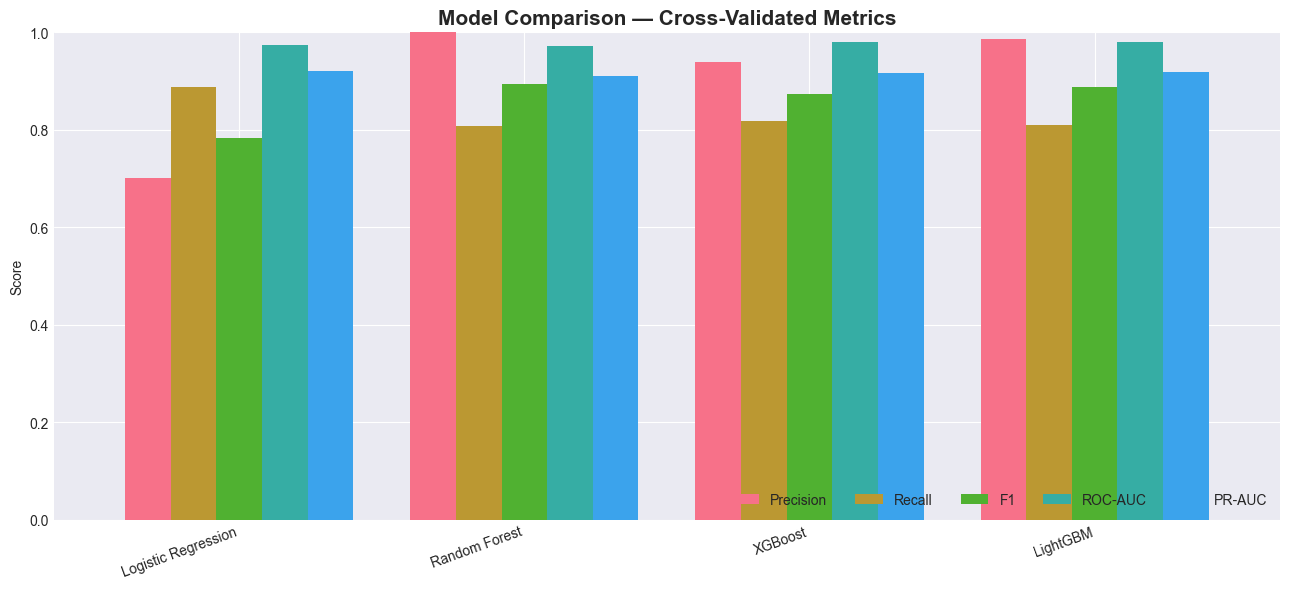


🏆 Best baseline model by PR-AUC: Logistic Regression


In [35]:
cv_df = pd.DataFrame(cv_results).set_index('Model')
cv_df_display = cv_df[['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'Fit_time_s']].round(4)

print('=' * 80)
print('CROSS-VALIDATED MODEL COMPARISON (5-fold, training set only)')
print('=' * 80)
print(cv_df_display)

# Visual comparison of the key imbalance-robust metrics
metrics_to_plot = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
ax = cv_df[metrics_to_plot].plot(kind='bar', figsize=(13, 6), width=0.8)
ax.set_title('Model Comparison — Cross-Validated Metrics', fontsize=15, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right', ncol=5)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../visualizations/05_model_comparison_cv.png', dpi=300)
plt.show()

best_baseline = cv_df['PR-AUC'].idxmax()
print(f'\n🏆 Best baseline model by PR-AUC: {best_baseline}')

## STEP 5.7: HYPERPARAMETER TUNING

The two gradient-boosted models (XGBoost, LightGBM) consistently lead on imbalanced fraud data, so we tune both with **randomized search** over a sensible grid, optimizing **average precision (PR-AUC)** — the most informative single metric when the positive class is rare. We then carry the stronger tuned model into validation.

### 5.7.1 Tune XGBoost

In [36]:
xgb_param_dist = {
    'n_estimators': [300, 400, 500, 700],
    'learning_rate': [0.02, 0.05, 0.1],
    'max_depth': [4, 5, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.5, 1.0],
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist,
    n_iter=25, scoring='average_precision',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)

print(f'\n✓ XGBoost best PR-AUC (CV): {xgb_search.best_score_:.4f}')
print(f'✓ Best params: {xgb_search.best_params_}')
xgb_best = xgb_search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits

✓ XGBoost best PR-AUC (CV): 0.9226
✓ Best params: {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.02, 'gamma': 1.0, 'colsample_bytree': 0.9}


### 5.7.2 Tune LightGBM

In [37]:
lgb_param_dist = {
    'n_estimators': [300, 400, 500, 700],
    'learning_rate': [0.02, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 6, 10],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_samples': [10, 20, 40],
}

lgb_base = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgb_search = RandomizedSearchCV(
    lgb_base, lgb_param_dist,
    n_iter=25, scoring='average_precision',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
lgb_search.fit(X_train, y_train)

print(f'\n✓ LightGBM best PR-AUC (CV): {lgb_search.best_score_:.4f}')
print(f'✓ Best params: {lgb_search.best_params_}')
lgb_best = lgb_search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits

✓ LightGBM best PR-AUC (CV): 0.9183
✓ Best params: {'subsample': 0.7, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.02, 'colsample_bytree': 0.7}


### 5.7.3 Select the champion model

In [38]:
tuned_scores = {
    'XGBoost (tuned)': xgb_search.best_score_,
    'LightGBM (tuned)': lgb_search.best_score_,
}
print('Tuned CV PR-AUC scores:')
for k, v in tuned_scores.items():
    print(f'  {k:<20}: {v:.4f}')

if xgb_search.best_score_ >= lgb_search.best_score_:
    champion_name, champion = 'XGBoost (tuned)', xgb_best
else:
    champion_name, champion = 'LightGBM (tuned)', lgb_best

print(f'\n🏆 CHAMPION MODEL → {champion_name}')

Tuned CV PR-AUC scores:
  XGBoost (tuned)     : 0.9226
  LightGBM (tuned)    : 0.9183

🏆 CHAMPION MODEL → XGBoost (tuned)


## STEP 6: VALIDATION & EXPLAINABILITY

We now run the champion model against the **untouched holdout test set** for an unbiased estimate of real-world performance, then use **SHAP** to explain *why* the model flags individual transactions as fraudulent.

### 6.1 Fit champion on full training set & predict on holdout

In [39]:
champion.fit(X_train, y_train)

y_pred = champion.predict(X_test)
y_proba = champion.predict_proba(X_test)[:, 1]

holdout_metrics = {
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'PR-AUC': average_precision_score(y_test, y_proba),
}

print('=' * 80)
print(f'HOLDOUT EVALUATION — {champion_name}')
print('=' * 80)
for k, v in holdout_metrics.items():
    print(f'  {k:<12}: {v:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud'], digits=4))

HOLDOUT EVALUATION — XGBoost (tuned)
  Precision   : 0.8137
  Recall      : 0.8342
  F1          : 0.8238
  ROC-AUC     : 0.9730
  PR-AUC      : 0.9025

Classification report:
              precision    recall  f1-score   support

  Legitimate     0.9838    0.9814    0.9826      2041
       Fraud     0.8137    0.8342    0.8238       199

    accuracy                         0.9683      2240
   macro avg     0.8988    0.9078    0.9032      2240
weighted avg     0.9687    0.9683    0.9685      2240



### 6.2 Confusion matrix

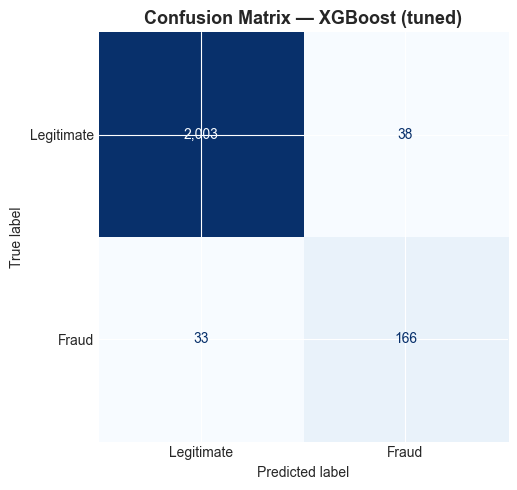

True Negatives (legit correctly cleared): 2,003
False Positives (legit flagged as fraud):  38
False Negatives (fraud missed):            33
True Positives (fraud caught):             166

Fraud capture rate (recall): 83.42%
False alarm rate (FPR):       1.86%


In [40]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format=',d')
ax.set_title(f'Confusion Matrix — {champion_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/05_confusion_matrix.png', dpi=300)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (legit correctly cleared): {tn:,}')
print(f'False Positives (legit flagged as fraud):  {fp:,}')
print(f'False Negatives (fraud missed):            {fn:,}')
print(f'True Positives (fraud caught):             {tp:,}')
print(f'\nFraud capture rate (recall): {tp / (tp + fn):.2%}')
print(f'False alarm rate (FPR):       {fp / (fp + tn):.2%}')

### 6.3 ROC curve & Precision-Recall curve

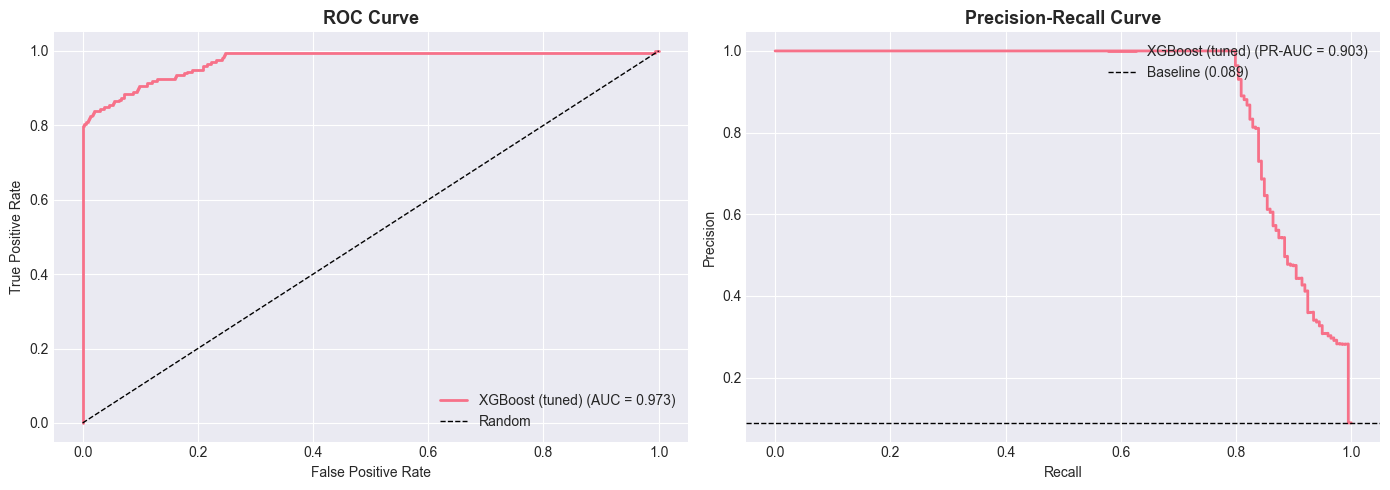

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, lw=2, label=f'{champion_name} (AUC = {holdout_metrics["ROC-AUC"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')

# Precision-Recall curve (more informative under imbalance)
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec, prec, lw=2, label=f'{champion_name} (PR-AUC = {holdout_metrics["PR-AUC"]:.3f})')
axes[1].axhline(y_test.mean(), color='k', ls='--', lw=1, label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('../visualizations/05_roc_pr_curves.png', dpi=300)
plt.show()

### 6.4 Threshold tuning for operations

The default 0.5 cut-off rarely matches business needs. Fraud teams usually pick a threshold that hits a target recall (catch rate) or caps the false-positive workload. Below we show how precision, recall, and F1 trade off across thresholds so the operations team can set a defensible decision boundary.

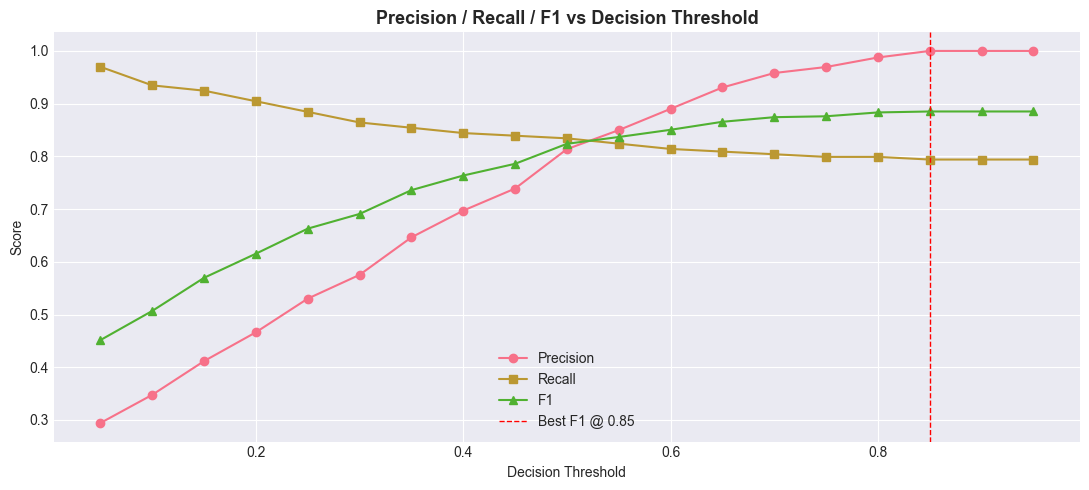

F1-optimal threshold: 0.85
 Threshold  Precision  Recall     F1
      0.05     0.2942  0.9698 0.4515
      0.10     0.3477  0.9347 0.5068
      0.15     0.4116  0.9246 0.5697
      0.20     0.4663  0.9045 0.6154
      0.25     0.5301  0.8844 0.6629
      0.30     0.5753  0.8643 0.6908
      0.35     0.6464  0.8543 0.7359
      0.40     0.6971  0.8442 0.7636
      0.45     0.7389  0.8392 0.7859
      0.50     0.8137  0.8342 0.8238
      0.55     0.8497  0.8241 0.8367
      0.60     0.8901  0.8141 0.8504
      0.65     0.9306  0.8090 0.8656
      0.70     0.9581  0.8040 0.8743
      0.75     0.9695  0.7990 0.8760
      0.80     0.9876  0.7990 0.8833
      0.85     1.0000  0.7940 0.8852
      0.90     1.0000  0.7940 0.8852
      0.95     1.0000  0.7940 0.8852


In [42]:
thresholds = np.linspace(0.05, 0.95, 19)
rows = []
for t in thresholds:
    pred_t = (y_proba >= t).astype(int)
    rows.append({
        'Threshold': t,
        'Precision': precision_score(y_test, pred_t, zero_division=0),
        'Recall': recall_score(y_test, pred_t, zero_division=0),
        'F1': f1_score(y_test, pred_t, zero_division=0),
    })
thr_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thr_df['Threshold'], thr_df['Precision'], marker='o', label='Precision')
ax.plot(thr_df['Threshold'], thr_df['Recall'], marker='s', label='Recall')
ax.plot(thr_df['Threshold'], thr_df['F1'], marker='^', label='F1')
best_t = thr_df.loc[thr_df['F1'].idxmax(), 'Threshold']
ax.axvline(best_t, color='red', ls='--', lw=1, label=f'Best F1 @ {best_t:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../visualizations/05_threshold_analysis.png', dpi=300)
plt.show()

print(f'F1-optimal threshold: {best_t:.2f}')
print(thr_df.round(4).to_string(index=False))

### 6.5 SHAP explainability — global feature importance

SHAP (SHapley Additive exPlanations) decomposes each prediction into additive feature contributions. The tree explainer is exact and fast for XGBoost/LightGBM. We sample the holdout set for the summary plots to keep computation tractable.

### 📚 IMPACT CHECK — the behaviour features are the payoff (watch the SHAP plot)

This is where the upstream identifier work pays off most visibly. We **could not** give the model a raw `customer_id` — but in cleaning Step 9 we turned identities into *behaviour*: `customer_total_transactions`, `customer_device_count`, `customer_ip_count`. 

Watch the SHAP importance plots below. Features engineered *from identifiers* typically rank among the strongest fraud signals — a customer touching many devices, or transacting at unusual velocity, is exactly the kind of pattern fraud teams care about. 

Contrast the two outcomes:
- **What we did:** identity → behaviour feature → top of the SHAP plot, *and the pattern generalises* to brand-new customers.
- **The alternative (raw IDs encoded):** 25,000 ID columns, each near-useless, the model memorising specific past fraudsters and failing on everyone new.

So when you read the SHAP plot, you are also reading a verdict on the data-prep decisions: the features that matter are the ones we deliberately engineered.

In [43]:
# Use a sample of the holdout set for SHAP (keeps plots readable and fast)
shap_sample_size = min(2000, X_test.shape[0])
X_shap = X_test.sample(shap_sample_size, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(champion)
shap_values = explainer.shap_values(X_shap)

# LightGBM/older APIs may return a list for binary classification — take positive class
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'✓ SHAP values computed for {shap_sample_size:,} holdout transactions')
print(f'  SHAP matrix shape: {np.array(shap_values).shape}')

✓ SHAP values computed for 2,000 holdout transactions
  SHAP matrix shape: (2000, 93)


#### 6.5.1 Global importance (bar)

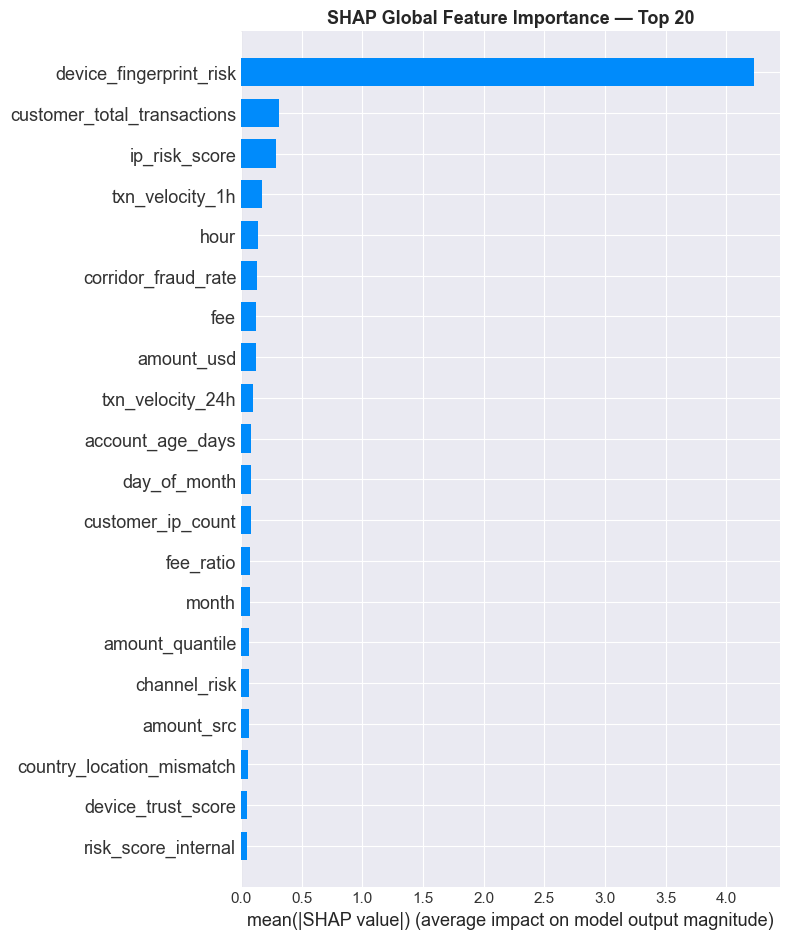

In [44]:
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Global Feature Importance — Top 20', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/05_shap_summary_bar.png', dpi=300)
plt.show()

#### 6.5.2 Beeswarm — direction & magnitude of effect

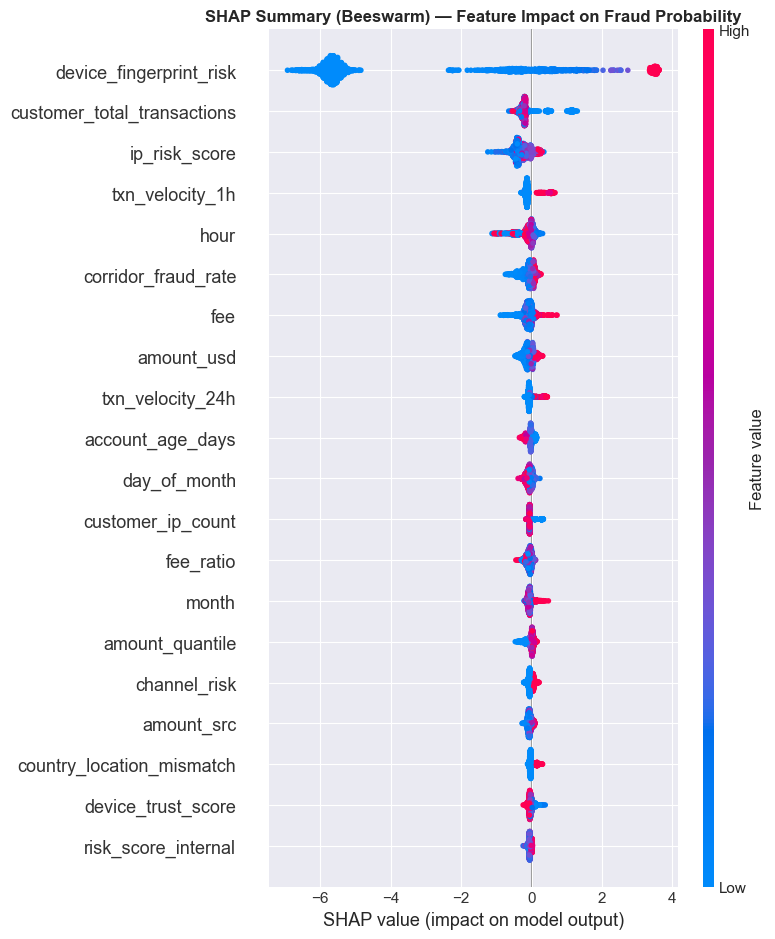

In [45]:
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title('SHAP Summary (Beeswarm) — Feature Impact on Fraud Probability', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/05_shap_summary_beeswarm.png', dpi=300)
plt.show()

### 6.6 Transaction-level explanations (build trust in individual decisions)

For investigators, the value of SHAP is per-transaction reasoning: *why was this specific transfer flagged?* Below we explain the highest-confidence fraud prediction in the holdout set with a waterfall plot.

Most confident fraud prediction:
  Predicted fraud probability: 0.9994
  Actual label: FRAUD


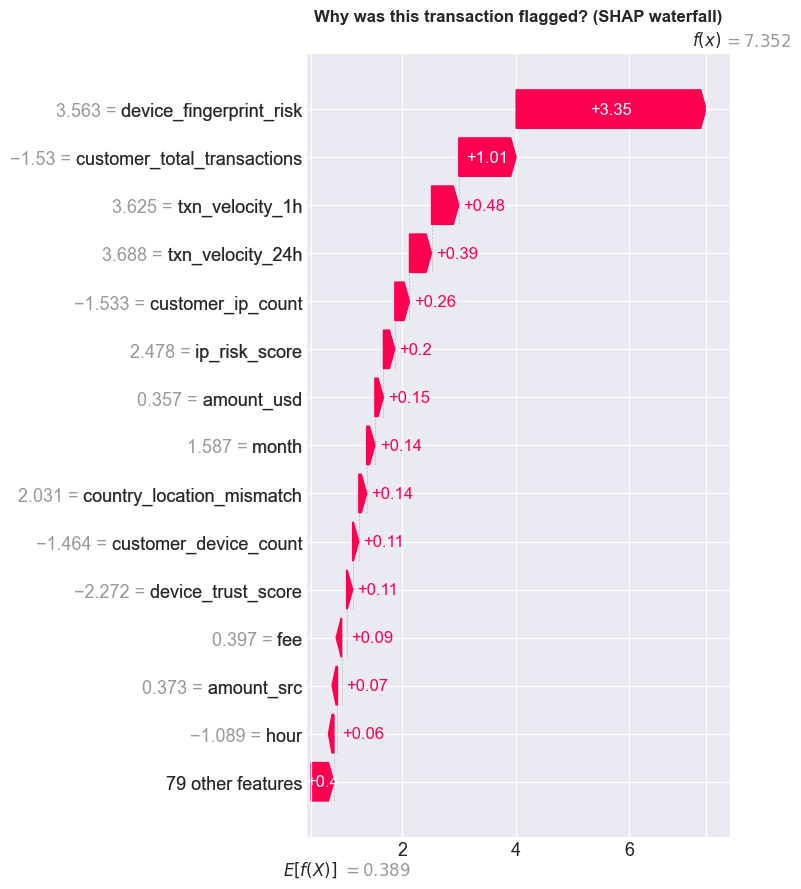

In [46]:
# Identify the holdout transaction the model is most confident is fraud
high_risk_idx = np.argsort(y_proba)[-1]
high_risk_row = X_test.iloc[[high_risk_idx]]

print(f'Most confident fraud prediction:')
print(f'  Predicted fraud probability: {y_proba[high_risk_idx]:.4f}')
print(f'  Actual label: {"FRAUD" if y_test.iloc[high_risk_idx] == 1 else "LEGITIMATE"}')

# Compute SHAP for this single transaction
single_shap = explainer(high_risk_row)
# Handle multiclass-style output
try:
    shap.plots.waterfall(single_shap[0], max_display=15, show=False)
except Exception:
    sv = single_shap.values
    if sv.ndim == 3:
        single_shap = single_shap[..., 1]
    shap.plots.waterfall(single_shap[0], max_display=15, show=False)
plt.title('Why was this transaction flagged? (SHAP waterfall)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/05_shap_waterfall_example.png', dpi=300)
plt.show()

## STEP 6.7: PERSIST THE CHAMPION MODEL

### 📚 IMPACT CHECK — saving the exact feature contract for deployment

We save `feature_cols` (the exact column names *and order* the model expects) alongside the model. This matters because of the upstream encoding decisions: the model was trained on specific one-hot columns like `channel_web`, `kyc_tier_enhanced`, plus the behaviour features. 

In deployment (Step 7), an incoming raw transaction must be put through **the identical cleaning, feature-engineering, and one-hot-encoding steps**, producing the identical columns in the identical order — otherwise the model receives a different "shape" of input than it learned from, and predictions become meaningless. Saving `feature_cols` makes that contract explicit and checkable. This is the final link in the chain: the cleaning and EDA logic is not just preparation, it becomes **part of the deployed system**.

In [47]:
# Save the trained champion model and the exact feature ordering it expects.
# Step 7 (Deployment / FastAPI /score endpoint) will load these artifacts.
model_path = '../models/nova_pay_fraud_model.joblib'
import os
os.makedirs('../models', exist_ok=True)

artifact = {
    'model': champion,
    'model_name': champion_name,
    'feature_cols': feature_cols,
    'decision_threshold': float(best_t),
    'holdout_metrics': holdout_metrics,
}
joblib.dump(artifact, model_path)

print(f'✓ Champion model saved to: {model_path}')
print(f'✓ Model: {champion_name}')
print(f'✓ Features expected: {len(feature_cols)}')
print(f'✓ Recommended decision threshold: {best_t:.2f}')

✓ Champion model saved to: ../models/nova_pay_fraud_model.joblib
✓ Model: XGBoost (tuned)
✓ Features expected: 93
✓ Recommended decision threshold: 0.85


## STEP 5 & 6 COMPLETE — SUMMARY

In [48]:
print('=' * 80)
print('STEP 5 & 6 COMPLETE: MODEL DEVELOPMENT, VALIDATION & EXPLAINABILITY')
print('=' * 80)

print('\n1. MODELS COMPARED (5-fold CV):')
print(cv_df[['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']].round(4).to_string())

print(f'\n2. CHAMPION MODEL: {champion_name}')

print('\n3. HOLDOUT PERFORMANCE:')
for k, v in holdout_metrics.items():
    print(f'   {k:<12}: {v:.4f}')

print(f'\n4. OPERATIONAL THRESHOLD (F1-optimal): {best_t:.2f}')

print('\n5. EXPLAINABILITY: SHAP global importance + transaction-level waterfall generated.')

print('\n6. ARTIFACT SAVED: ../models/nova_pay_fraud_model.joblib')
print('\n➡  NEXT — Step 7: Deployment (FastAPI /score endpoint + Docker containerization).')

print('\n' + '=' * 80)
print('HOW UPSTREAM DECISIONS SHAPED THESE RESULTS')
print('=' * 80)
print('• Identifier separation (EDA 3.10b)  -> compact feature matrix, no ID leakage')
print('• Behaviour features (cleaning S9)   -> top SHAP signals, generalise to new users')
print('• One-hot encoding (EDA 3.10)        -> usable categorical inputs, no false order')
print('• KNN imputation (cleaning S7)       -> no NaNs crash training; distribution kept')
print('• Outlier capping (cleaning S6)      -> stable scaling & tree splits')
print('• Scaling (EDA 3.9)                  -> fair linear model; 0-fill = mean is valid')
print('• Imbalance documented (cleaning S10)-> stratified split, class weights, PR-AUC')
print('\n📌 LESSON: the model is only as good as the pipeline that fed it.')

STEP 5 & 6 COMPLETE: MODEL DEVELOPMENT, VALIDATION & EXPLAINABILITY

1. MODELS COMPARED (5-fold CV):
                     Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                          
Logistic Regression     0.7007  0.8882  0.7833   0.9739  0.9211
Random Forest           1.0000  0.8078  0.8934   0.9726  0.9110
XGBoost                 0.9395  0.8178  0.8741   0.9799  0.9159
LightGBM                0.9860  0.8090  0.8887   0.9792  0.9178

2. CHAMPION MODEL: XGBoost (tuned)

3. HOLDOUT PERFORMANCE:
   Precision   : 0.8137
   Recall      : 0.8342
   F1          : 0.8238
   ROC-AUC     : 0.9730
   PR-AUC      : 0.9025

4. OPERATIONAL THRESHOLD (F1-optimal): 0.85

5. EXPLAINABILITY: SHAP global importance + transaction-level waterfall generated.

6. ARTIFACT SAVED: ../models/nova_pay_fraud_model.joblib

➡  NEXT — Step 7: Deployment (FastAPI /score endpoint + Docker containerization).

HOW UPSTREAM DECISIONS SHAPED THESE RESULTS
• Identifier separa